# Cross-Market Arbitrage: KXNBAGAME vs KXNBASPREAD

Explores temporal price divergences between the win/loss market (KXNBAGAME) and the
spread market at the 1.5-point strike (KXNBASPREAD) using **live WebSocket trade data**
from the bronze ingester (Apr 18-21, 2026).

**Data source:** `materialized/kalshi_ws/trade.parquet` — all trades captured by the
live WS ingester. No historical REST data used. Game outcomes from `nba_cdn/boxscore/`.

**Fee model:** Kalshi NBA series (kalshi.com/fee-schedule):
- Taker: `0.07 * C * (1-C)` per contract
- Maker: 25% of taker = `0.0175 * C * (1-C)` per contract

## Setup

Standard imports + S3 client. All data lives in `s3://prediction-markets-data/`.

In [39]:
import json
import gzip
import re
import gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

s3 = boto3.client("s3")
S3_BUCKET = "prediction-markets-data"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 1. Cross-Market Arbitrage: KXNBASPREAD → Implied P(Win) vs KXNBAGAME

### The two contracts

Both markets are binary ($0 or $1 at settlement). For a given game, say **LAL vs DAL**:

| Contract | Pays $1 if... |
|---|---|
| `KXNBAGAME-LAL` (YES) | LAL wins the game |
| `KXNBASPREAD-LAL-1.5` (YES) | LAL wins by **2 or more** points |

The spread contract is *strictly harder to win* than the game contract, because it excludes the case "LAL wins by exactly 1 point." So:

```
P(LAL wins)  =  P(LAL wins by ≥2)  +  P(LAL wins by exactly 1)
```

In a fair market, GAME should trade ~2-3¢ above SPREAD@1.5, reflecting the ~2-3% chance of a 1-point win.

### The trade (when gap is too wide)

Suppose during the game:

```
GAME-LAL YES       :  $0.68   →  GAME-LAL NO costs $0.32
SPREAD-LAL-1.5 YES :  $0.63
gap                :  $0.05   (should be ~$0.02-0.03)
```

The gap is wider than it should be, so we trade the spread:

- **Buy GAME-LAL NO @ $0.32** → pays $1 if LAL loses, $0 if LAL wins
- **Buy SPREAD-LAL-1.5 YES @ $0.63** → pays $1 if LAL wins by ≥2, $0 otherwise

**Total cost: $0.32 + $0.63 = $0.95**

Now we wait for the game to end. Three things can happen:

---

**Outcome A: LAL wins by ≥2 points (e.g., 110-105)**

| Position | Cost | Settles to | Profit/Loss |
|---|---|---|---|
| GAME NO | $0.32 | $0 (LAL won) | **-$0.32** |
| SPREAD YES | $0.63 | $1 (LAL won by ≥2) | **+$0.37** |
| **Total** | **$0.95** | **$1.00** | **+$0.05** |

GAME NO is a total loss (LAL won). But SPREAD YES pays out. Net: +$0.05.

---

**Outcome B: LAL wins by exactly 1 point (e.g., 105-104)**

| Position | Cost | Settles to | Profit/Loss |
|---|---|---|---|
| GAME NO | $0.32 | $0 (LAL won) | **-$0.32** |
| SPREAD YES | $0.63 | $0 (LAL won by only 1) | **-$0.63** |
| **Total** | **$0.95** | **$0.00** | **-$0.95** |

Both legs lose. LAL won, so GAME NO is worthless. LAL only won by 1, so SPREAD YES is also worthless. We lose our entire $0.95.

---

**Outcome C: LAL loses (e.g., 100-108)**

| Position | Cost | Settles to | Profit/Loss |
|---|---|---|---|
| GAME NO | $0.32 | $1 (LAL lost) | **+$0.68** |
| SPREAD YES | $0.63 | $0 (LAL lost) | **-$0.63** |
| **Total** | **$0.95** | **$1.00** | **+$0.05** |

GAME NO pays $1 (LAL lost). SPREAD YES is worthless (LAL didn't win at all). Net: +$0.05.

---

### Summary and expected value

| Outcome | Probability | Payout | Cost | P&L |
|---|---|---|---|---|
| LAL wins by ≥2 | ~65% | $1.00 | $0.95 | +$0.05 |
| LAL wins by 1 | ~2% | $0.00 | $0.95 | -$0.95 |
| LAL loses | ~33% | $1.00 | $0.95 | +$0.05 |

**In 2 of 3 outcomes, exactly one leg pays $1 and we profit $0.05. In the 1-point case, neither leg pays and we lose everything.**

Expected P&L ≈ $0.05 × 98% - $0.95 × 2% ≈ **+$0.03 per pair**

Positive EV of ~3¢ per contract pair — but **one 1-point game wipes out 19 successful trades**. This is a statistical arb, not a risk-free arb.

### Why this is hard to profit from

1. **Fat tail risk.** 4.2% of NBA games are decided by 1 point. At a 5¢ entry credit, you need 19:1 ratio of normal outcomes to 1-point outcomes just to break even.
2. **Fees.** Kalshi charges ~$0.02/leg ($0.04 round-trip), eating most of the $0.05 credit.
3. **SPREAD@1.5 is relatively illiquid.** Median ~100 trades per game vs thousands for GAME (exact comparison computed in §4 below). You often can't execute the SPREAD leg at the price you see.
4. **Execution risk.** If you fill one leg but not the other, you're not hedged — you're just betting on the game.

### What this notebook measures

The cells below quantify: (1) how often the gap exceeds a tradeable threshold, (2) what the realized P&L looks like using actual game outcomes, and (3) at what threshold the edge overcomes 1-point risk + fees.

## 2. Load live trade data

Load all WS trades from the materialized Parquet file (one read vs hundreds of S3 fetches).
Discover GAME ↔ SPREAD@1.5 pairs from the tickers present in the live data,
build divergence time series, and prepare `all_game_data` for the backtest cells below.

**Data source:** `materialized/kalshi_ws/trade.parquet` — all trades captured by the
live WebSocket ingester. No historical REST data used.

In [40]:
# --- Load all live trades from materialized Parquet ---
import pyarrow.parquet as pq
import io

obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/trade.parquet")
trades_df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
trades_df["t_dt"] = pd.to_datetime(trades_df["t_receipt"], unit="s", utc=True)
print(f"Loaded {len(trades_df):,} live trades across {trades_df['ticker'].nunique()} tickers")
print(f"Time range: {trades_df['t_dt'].min()} to {trades_df['t_dt'].max()}")

# Discover GAME ↔ SPREAD@1.5 pairs from available tickers
game_tickers = [t for t in trades_df["ticker"].unique() if t.startswith("KXNBAGAME-")]
spread_tickers = set(t for t in trades_df["ticker"].unique() if t.startswith("KXNBASPREAD-"))

pairs = []
for gt in game_tickers:
    # KXNBAGAME-26APR18ATLNYK-ATL → game_key=26APR18ATLNYK, team=ATL
    parts = gt.split("-")
    game_key = parts[1]
    team = parts[2]
    # SPREAD@1.5 ticker: KXNBASPREAD-{game_key}-{team}1
    spread_ticker = f"KXNBASPREAD-{game_key}-{team}1"
    if spread_ticker in spread_tickers:
        pairs.append({
            "game_key": game_key,
            "team": team,
            "game_ticker": gt,
            "spread_ticker": spread_ticker,
        })

print(f"\nGAME ↔ SPREAD@1.5 pairs in live data: {len(pairs)}")
print(f"Unique games: {len(set(p['game_key'] for p in pairs))}")
for p in pairs[:10]:
    gt_n = len(trades_df[trades_df['ticker'] == p['game_ticker']])
    st_n = len(trades_df[trades_df['ticker'] == p['spread_ticker']])
    print(f"  {p['game_ticker']:45s} ({gt_n:>6,}) ↔ {p['spread_ticker']} ({st_n:>5,})")
if len(pairs) > 10:
    print(f"  ... and {len(pairs) - 10} more")

Loaded 1,074,831 live trades across 944 tickers
Time range: 2026-04-19 00:15:13.696224451+00:00 to 2026-04-22 00:38:08.940552950+00:00

GAME ↔ SPREAD@1.5 pairs in live data: 9
Unique games: 9
  KXNBAGAME-26APR18HOULAL-LAL                   (38,339) ↔ KXNBASPREAD-26APR18HOULAL-LAL1 (2,973)
  KXNBAGAME-26APR21HOULAL-HOU                   ( 4,848) ↔ KXNBASPREAD-26APR21HOULAL-HOU1 (  253)
  KXNBAGAME-26APR19PHIBOS-BOS                   ( 7,408) ↔ KXNBASPREAD-26APR19PHIBOS-BOS1 (  104)
  KXNBAGAME-26APR23NYKATL-NYK                   ( 1,261) ↔ KXNBASPREAD-26APR23NYKATL-NYK1 (   88)
  KXNBAGAME-26APR19PORSAS-POR                   (31,010) ↔ KXNBASPREAD-26APR19PORSAS-POR1 (  327)
  KXNBAGAME-26APR20MINDEN-DEN                   (41,565) ↔ KXNBASPREAD-26APR20MINDEN-DEN1 (2,468)
  KXNBAGAME-26APR20ATLNYK-NYK                   (38,754) ↔ KXNBASPREAD-26APR20ATLNYK-NYK1 (1,888)
  KXNBAGAME-26APR23DENMIN-DEN                   (   730) ↔ KXNBASPREAD-26APR23DENMIN-DEN1 (   32)
  KXNBAGAME-26APR21PORSA

### Build divergence time series + game outcomes

For each pair, resample GAME and SPREAD@1.5 trades at 30s intervals,
compute the price divergence, and apply the same staleness filter as before
(only count bins where SPREAD traded within the last 5 minutes).

Also load game outcomes from box scores for settlement P&L calculation.

In [41]:
# --- Build divergence time series from live trades ---

def measure_divergence_strict(game_trades, spread_trades, freq="30s", max_stale_bins=10):
    """Resample both trade series; only keep bins where SPREAD traded within 5 min."""
    if game_trades.empty or spread_trades.empty:
        return pd.DataFrame()
    gt = game_trades.set_index("t_dt")["yes_price"].resample(freq).last()
    st = spread_trades.set_index("t_dt")["yes_price"].resample(freq).last()
    st_has_trade = st.notna()
    gt_filled = gt.ffill()
    st_filled = st.ffill()
    st_stale_counter = pd.Series(0, index=st.index, dtype=int)
    count = 0
    for i in range(len(st_has_trade)):
        if st_has_trade.iloc[i]:
            count = 0
        else:
            count += 1
        st_stale_counter.iloc[i] = count
    combined = pd.DataFrame({
        "game_price": gt_filled,
        "spread_price": st_filled,
        "spread_stale_bins": st_stale_counter,
    }).dropna(subset=["game_price", "spread_price"])
    combined = combined[combined["spread_stale_bins"] <= max_stale_bins]
    if combined.empty:
        return combined
    combined["divergence"] = combined["game_price"] - combined["spread_price"]
    return combined

# --- Load game outcomes from boxscores ---
print("Loading game outcomes from boxscores...")
paginator = s3.get_paginator("list_objects_v2")
box_keys = []
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix="nba_cdn/boxscore/"):
    box_keys.extend([o["Key"] for o in page.get("Contents", [])])

def load_boxscore(key):
    try:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
        box = json.loads(obj["Body"].read())
        g = box["game"]
        return {"game_id": g["gameId"], "home_team": g["homeTeam"]["teamTricode"],
                "away_team": g["awayTeam"]["teamTricode"],
                "home_score": g["homeTeam"]["score"], "away_score": g["awayTeam"]["score"]}
    except: return None

outcomes = []
with ThreadPoolExecutor(max_workers=16) as pool:
    futures = {pool.submit(load_boxscore, k): k for k in box_keys}
    for f in as_completed(futures):
        r = f.result()
        if r and r["home_score"] > 0:
            outcomes.append(r)

outcomes_df = pd.DataFrame(outcomes)
outcomes_df["margin"] = abs(outcomes_df["home_score"] - outcomes_df["away_score"])
outcomes_df["winner"] = np.where(
    outcomes_df["home_score"] > outcomes_df["away_score"],
    outcomes_df["home_team"], outcomes_df["away_team"])
print(f"Loaded {len(outcomes_df)} game outcomes")

# Match game_key → outcome
def parse_game_key(gk):
    return gk[7:10], gk[10:13]  # away, home

game_key_to_outcome = {}
live_game_keys = set(p["game_key"] for p in pairs)
for gk in live_game_keys:
    away, home = parse_game_key(gk)
    match = outcomes_df[
        (outcomes_df["home_team"] == home) & (outcomes_df["away_team"] == away)]
    if len(match) >= 1:
        game_key_to_outcome[gk] = {
            "margin": match.iloc[-1]["margin"],
            "winner": match.iloc[-1]["winner"],
            "home_team": home, "away_team": away}

print(f"Matched {len(game_key_to_outcome)}/{len(live_game_keys)} live game keys to outcomes")

# --- Build all_game_data ---
print(f"\nBuilding divergence time series for {len(pairs)} pairs...")
all_game_data = []
for pair in pairs:
    gt = trades_df[trades_df["ticker"] == pair["game_ticker"]].sort_values("t_receipt")
    st = trades_df[trades_df["ticker"] == pair["spread_ticker"]].sort_values("t_receipt")
    if gt.empty or st.empty:
        continue
    div = measure_divergence_strict(gt, st)
    if div.empty:
        continue
    all_game_data.append({
        "game_key": pair["game_key"],
        "team": pair["team"],
        "div_df": div,
        "n_game_trades": len(gt),
        "n_spread_trades": len(st),
    })

print(f"Pairs with divergence data: {len(all_game_data)}")
if all_game_data:
    all_div = pd.concat([d["div_df"]["divergence"] for d in all_game_data])
    print(f"Total time-aligned observations: {len(all_div):,}")
    print(f"Mean divergence:  ${all_div.mean():.4f}")
    print(f"Median:           ${all_div.median():.4f}")
    print(f"Std:              ${all_div.std():.4f}")
    print(f"|div| > $0.03:   {(all_div.abs() > 0.03).mean():.1%}")
    print(f"|div| > $0.05:   {(all_div.abs() > 0.05).mean():.1%}")
    print(f"|div| > $0.10:   {(all_div.abs() > 0.10).mean():.1%}")

    # Liquidity comparison
    game_counts = [d["n_game_trades"] for d in all_game_data]
    spread_counts = [d["n_spread_trades"] for d in all_game_data]
    print(f"\nLIQUIDITY: GAME vs SPREAD@1.5")
    print(f"  GAME trades/pair:   median {np.median(game_counts):,.0f}, mean {np.mean(game_counts):,.0f}")
    print(f"  SPREAD trades/pair: median {np.median(spread_counts):,.0f}, mean {np.mean(spread_counts):,.0f}")
    print(f"  Ratio:              {np.median(game_counts)/max(np.median(spread_counts),1):.0f}x")

Loading game outcomes from boxscores...
Loaded 1321 game outcomes
Matched 9/9 live game keys to outcomes

Building divergence time series for 9 pairs...
Pairs with divergence data: 9
Total time-aligned observations: 6,021
Mean divergence:  $0.0245
Median:           $0.0200
Std:              $0.0203
|div| > $0.03:   37.4%
|div| > $0.05:   7.7%
|div| > $0.10:   0.3%

LIQUIDITY: GAME vs SPREAD@1.5
  GAME trades/pair:   median 7,870, mean 19,087
  SPREAD trades/pair: median 253, mean 925
  Ratio:              31x


### Price time series: GAME vs SPREAD@1.5

Step plots showing how GAME and SPREAD@1.5 YES prices move during the live-captured games.

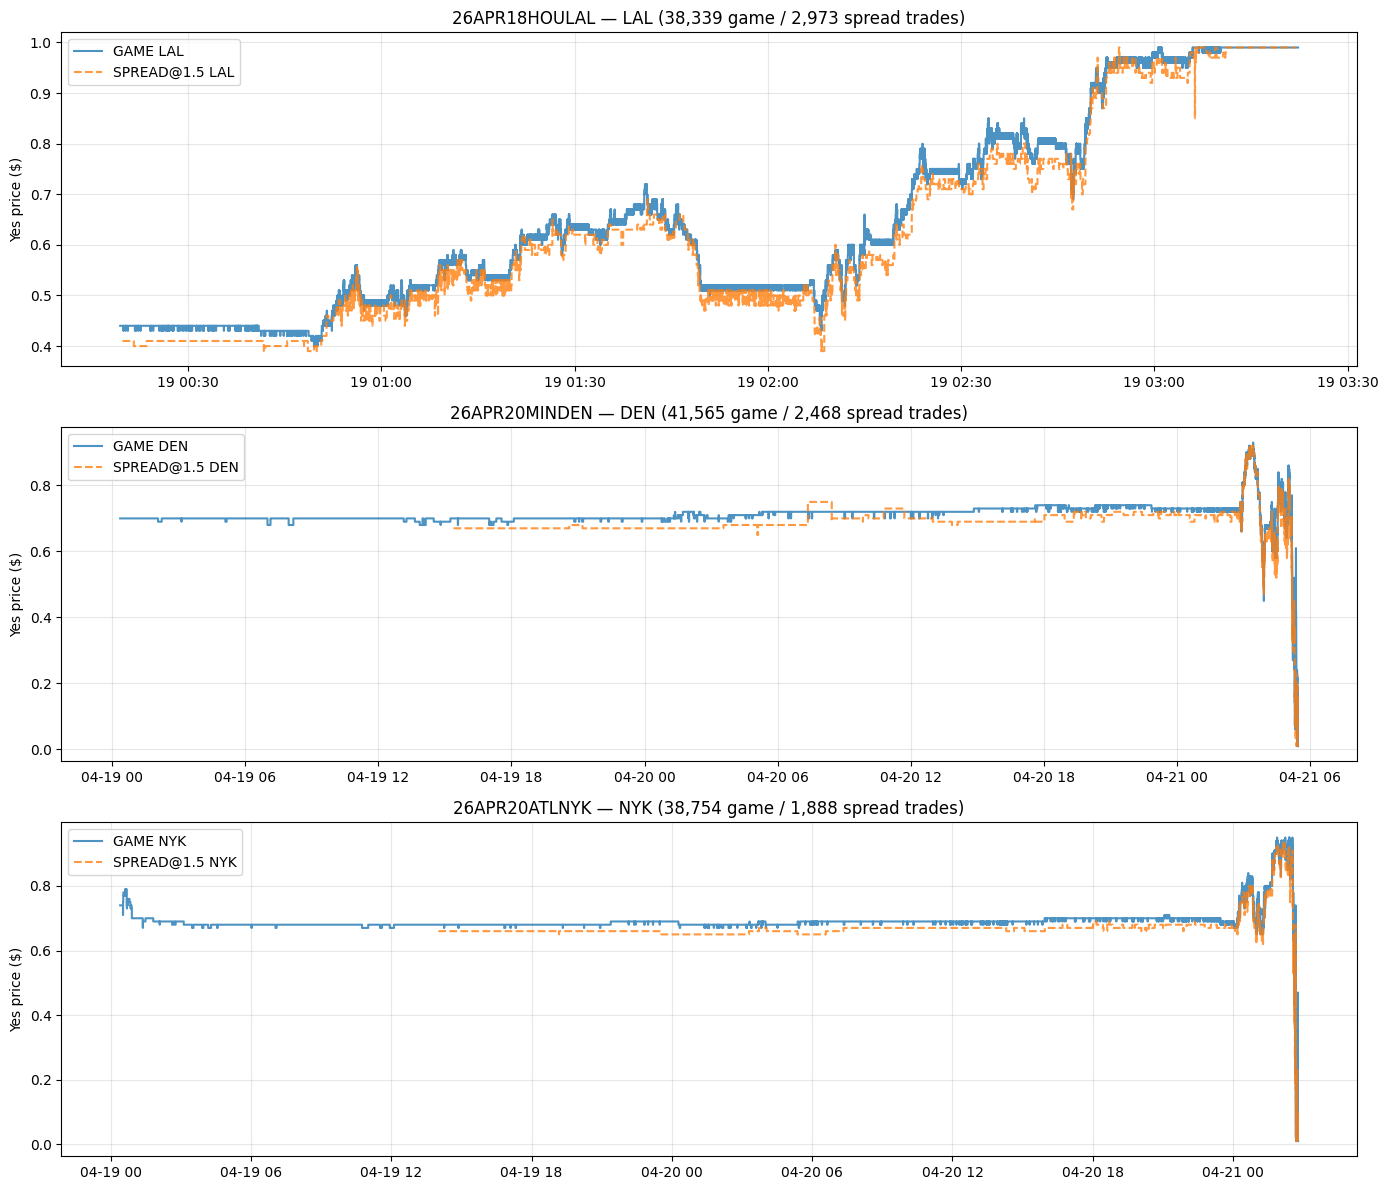

In [42]:
# Plot GAME vs SPREAD@1.5 for the pairs with most trade activity
top_pairs = sorted(all_game_data, key=lambda d: d["n_spread_trades"], reverse=True)
n_plot = min(3, len(top_pairs))

if n_plot > 0:
    fig, axes = plt.subplots(n_plot, 1, figsize=(14, 4 * n_plot), squeeze=False)
    for i, gd in enumerate(top_pairs[:n_plot]):
        ax = axes[i, 0]
        gt = trades_df[trades_df["ticker"] == pairs[0]["game_ticker"]]
        # Find matching pair
        for p in pairs:
            if p["game_key"] == gd["game_key"] and p["team"] == gd["team"]:
                gt = trades_df[trades_df["ticker"] == p["game_ticker"]].sort_values("t_dt")
                st = trades_df[trades_df["ticker"] == p["spread_ticker"]].sort_values("t_dt")
                break
        ax.step(gt["t_dt"], gt["yes_price"], where="post", label=f"GAME {gd['team']}", alpha=0.8)
        ax.step(st["t_dt"], st["yes_price"], where="post", label=f"SPREAD@1.5 {gd['team']}", alpha=0.8, linestyle="--")
        ax.set_title(f"{gd['game_key']} — {gd['team']} ({gd['n_game_trades']:,} game / {gd['n_spread_trades']:,} spread trades)")
        ax.set_ylabel("Yes price ($)")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No pairs with trade data to plot.")

## 3. Executable divergence: order book bid/ask vs last-trade prices

The divergence above uses **last traded prices**, but to execute the arb you need to
cross the spread:

- To sell GAME: hit the GAME **bid** (below last trade)
- To buy SPREAD@1.5: hit the SPREAD **ask** (above last trade)

So the real executable divergence is `GAME_bid - SPREAD_ask`, which is **narrower**
than `GAME_last - SPREAD_last`. Trade-price divergence overstates the opportunity.

This section reconstructs order books for both GAME and SPREAD@1.5 from live
snapshot+delta data, then measures the executable divergence at each point in time.
This tells us: when we see a signal, can we actually capture it at the quoted prices?

### Why trade prices overstate the opportunity

Last-trade prices show where the **last** trade happened, not where the **next** trade can happen. This distinction matters enormously for cross-market arbitrage.

**The staleness problem.** SPREAD@1.5 markets trade ~31x less frequently than GAME markets. When you see a SPREAD last-trade price of $0.72, that trade might be minutes old. The current order book could look completely different. Using stale prices to measure divergence is like navigating with yesterday's map.

**The crossing-cost problem.** Even with fresh prices, execution costs more than mid-price analysis suggests. To capture a divergence where GAME is overpriced relative to SPREAD, you need to:

- **Sell GAME** by hitting the bid (below mid)
- **Buy SPREAD** by lifting the ask (above mid)

Both directions cost you half the bid-ask spread.

**A concrete example.** Suppose mid-prices show a $0.05 divergence:

| | Mid | Bid | Ask | Spread |
|---|---|---|---|---|
| GAME | $0.78 | $0.77 | $0.79 | $0.02 |
| SPREAD@1.5 | $0.73 | $0.71 | $0.75 | $0.04 |

- **Apparent divergence** (mid - mid): $0.78 - $0.73 = **$0.05**
- **Executable divergence** (bid - ask): $0.77 - $0.75 = **$0.02**

The crossing cost ate $0.03 — more than half the signal. With typical spreads of $0.01-0.02 on GAME and $0.03-0.04 on SPREAD, roughly **$0.02-0.03 of any apparent divergence is just the cost of crossing the spread**, not real alpha.

This is exactly why backtests on trade prices look better than live execution. The bid-ask spread is an invisible tax that trade-price analysis misses entirely.

Snapshots: 7,209 | Deltas: 10,214,186

Reconstructing order books for 9 pairs (all sessions)...
  KXNBAGAME-26APR18HOULAL-LAL: 24 aligned book states
  KXNBAGAME-26APR21HOULAL-HOU: no time overlap after merge
  KXNBAGAME-26APR19PHIBOS-BOS: 17 aligned book states
  KXNBAGAME-26APR23NYKATL-NYK: game=2718, spread=0 — skipped
  KXNBAGAME-26APR19PORSAS-POR: 17 aligned book states
  KXNBAGAME-26APR20MINDEN-DEN: no time overlap after merge
  KXNBAGAME-26APR20ATLNYK-NYK: no time overlap after merge
  KXNBAGAME-26APR23DENMIN-DEN: game=2311, spread=0 — skipped
  KXNBAGAME-26APR21PORSAS-SAS: game=3121, spread=0 — skipped

Total: 58 book states across 3 games

DIVERGENCE COMPARISON: trade-price vs executable
                                   Trade-price       Executable
-----------------------------------------------------------------
Mean                           $        0.0205  $        0.0083
Median                         $        0.0250  $        0.0100
Std                            $    

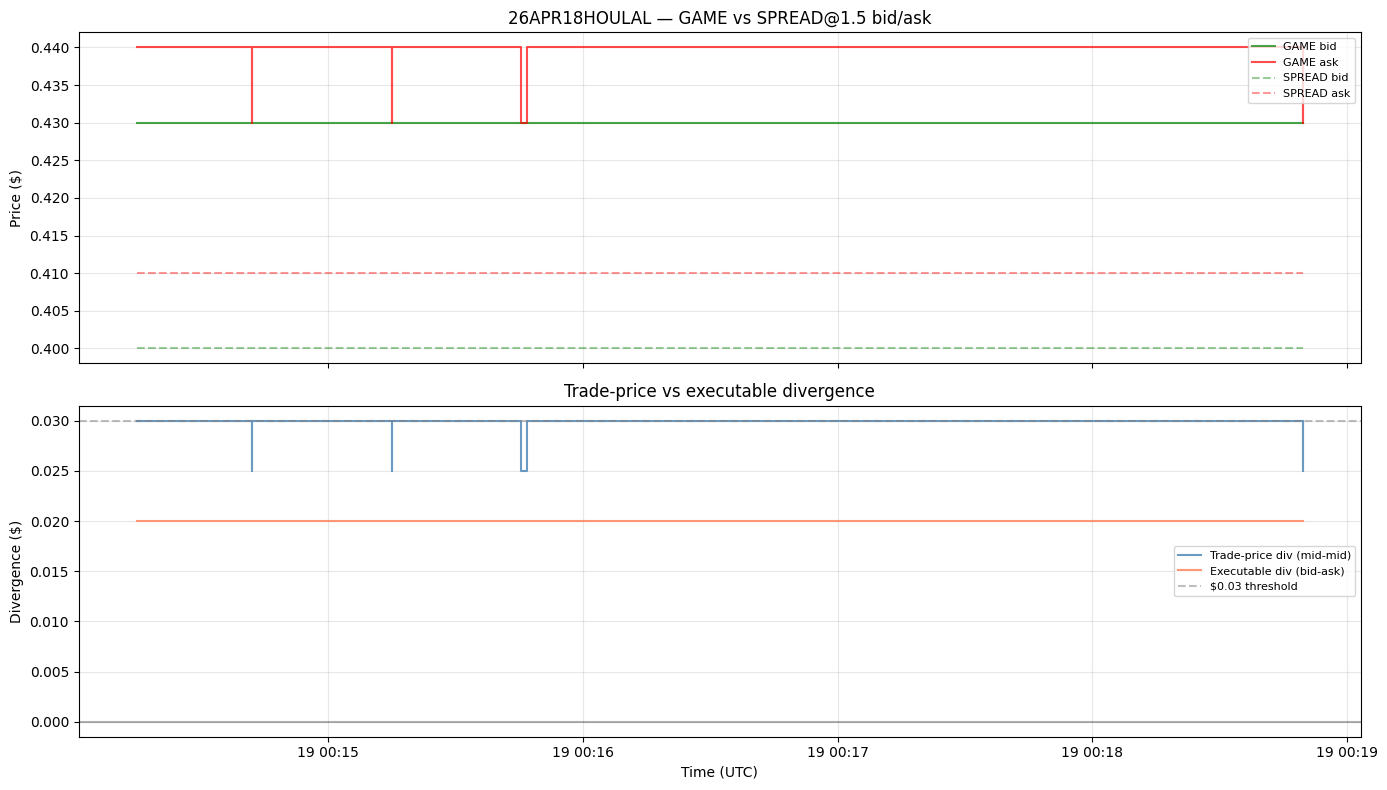

In [43]:
# --- Executable divergence from reconstructed order books ---
import pyarrow.parquet as pq

MIN_SIZE = 0.5  # phantom level cleanup

# Load snapshots and deltas
obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/orderbook_snapshot.parquet")
snap_df_ob = pd.read_parquet(io.BytesIO(obj["Body"].read()))

obj = s3.get_object(Bucket=S3_BUCKET, Key="materialized/kalshi_ws/orderbook_delta.parquet")
delta_df_ob = pd.read_parquet(io.BytesIO(obj["Body"].read()))

print(f"Snapshots: {len(snap_df_ob):,} | Deltas: {len(delta_df_ob):,}")

# Build ALL snapshots per ticker (not just last one)
all_snaps = {}  # ticker → list of snap dicts
for _, row in snap_df_ob.iterrows():
    if pd.isna(row.get("yes_book_json")) or pd.isna(row.get("no_book_json")):
        continue
    tk = row["ticker"]
    if tk not in all_snaps:
        all_snaps[tk] = []
    all_snaps[tk].append({
        "conn_id": row.get("conn_id"),
        "t_receipt": row["t_receipt"],
        "yes_book": json.loads(row["yes_book_json"]),
        "no_book": json.loads(row["no_book_json"]),
    })

def get_deltas_for(ticker, meta, delta_df, window_hrs=4):
    conn_id, t0 = meta.get("conn_id"), meta["t_receipt"]
    if pd.notna(conn_id):
        return delta_df[
            (delta_df["ticker"] == ticker) &
            (delta_df["conn_id"] == conn_id) &
            (delta_df["t_receipt"] > t0)
        ].sort_values("t_receipt")
    else:
        return delta_df[
            (delta_df["ticker"] == ticker) &
            (delta_df["t_receipt"] > t0) &
            (delta_df["t_receipt"] < t0 + window_hrs * 3600)
        ].sort_values("t_receipt")

def reconstruct_one(ticker, meta, delta_df, sample_interval=30):
    """Reconstruct book from one snapshot. Returns list of (t, bid, ask, bid_depth, ask_depth)."""
    yes_bk = {p: float(s) for p, s in meta["yes_book"]}
    no_bk = {p: float(s) for p, s in meta["no_book"]}
    t0 = meta["t_receipt"]
    tk_d = get_deltas_for(ticker, meta, delta_df)
    if tk_d.empty:
        return []

    def snap():
        yp = [(float(p), s) for p, s in yes_bk.items() if s > MIN_SIZE]
        np_ = [(float(p), s) for p, s in no_bk.items() if s > MIN_SIZE]
        if not yp or not np_:
            return None
        bb_p, bb_sz = max(yp, key=lambda x: x[0])
        bno_p, bno_sz = max(np_, key=lambda x: x[0])
        ba_p = round(1.0 - bno_p, 4)
        return (bb_p, ba_p, bb_sz, bno_sz)

    states = []
    s = snap()
    if s:
        states.append((t0, *s))
    next_sample = t0 + sample_interval
    for _, row in tk_d.iterrows():
        pk = f"{row['price']:.4f}"
        book = yes_bk if row["side"] == "yes" else no_bk
        ns = book.get(pk, 0.0) + row["delta"]
        if ns < MIN_SIZE:
            book.pop(pk, None)
        else:
            book[pk] = ns
        if row["t_receipt"] >= next_sample:
            s = snap()
            if s:
                states.append((row["t_receipt"], *s))
            next_sample = row["t_receipt"] + sample_interval
    return states

def reconstruct_all_sessions(ticker, delta_df, sample_interval=30):
    """Reconstruct book across ALL snapshots for a ticker, concatenate."""
    snaps = all_snaps.get(ticker, [])
    if not snaps:
        return []
    all_states = []
    for meta in snaps:
        states = reconstruct_one(ticker, meta, delta_df, sample_interval)
        all_states.extend(states)
    # Sort by time and deduplicate
    all_states.sort(key=lambda x: x[0])
    return all_states

# Reconstruct books for all live pairs
print(f"\nReconstructing order books for {len(pairs)} pairs (all sessions)...")
exec_results = []
for pair in pairs:
    game_states = reconstruct_all_sessions(pair["game_ticker"], delta_df_ob)
    spread_states = reconstruct_all_sessions(pair["spread_ticker"], delta_df_ob)
    if not game_states or not spread_states:
        print(f"  {pair['game_ticker']}: game={len(game_states)}, spread={len(spread_states)} — skipped")
        continue

    game_bk = pd.DataFrame(game_states, columns=["t", "game_bid", "game_ask", "game_bid_depth", "game_ask_depth"])
    spread_bk = pd.DataFrame(spread_states, columns=["t", "spread_bid", "spread_ask", "spread_bid_depth", "spread_ask_depth"])

    combined = pd.merge_asof(
        game_bk.sort_values("t"), spread_bk.sort_values("t"),
        on="t", tolerance=60, direction="nearest"
    ).dropna()
    if combined.empty:
        print(f"  {pair['game_ticker']}: no time overlap after merge")
        continue

    # Trade-price divergence (mid-mid)
    combined["trade_div"] = (combined["game_bid"] + combined["game_ask"]) / 2 - \
                            (combined["spread_bid"] + combined["spread_ask"]) / 2
    # Executable divergence
    combined["exec_div_sell"] = combined["game_bid"] - combined["spread_ask"]
    combined["exec_div_buy"] = combined["spread_bid"] - combined["game_ask"]
    combined["exec_div"] = combined[["exec_div_sell", "exec_div_buy"]].max(axis=1)
    combined["exec_direction"] = np.where(
        combined["exec_div_sell"] >= combined["exec_div_buy"], "sell_game", "buy_game")
    combined["exec_depth"] = np.where(
        combined["exec_direction"] == "sell_game",
        combined[["game_bid_depth", "spread_ask_depth"]].min(axis=1),
        combined[["game_ask_depth", "spread_bid_depth"]].min(axis=1))
    combined["game_key"] = pair["game_key"]
    combined["team"] = pair["team"]
    exec_results.append(combined)
    print(f"  {pair['game_ticker']}: {len(combined):,} aligned book states")

if exec_results:
    exec_df = pd.concat(exec_results, ignore_index=True)
    exec_df["t_dt"] = pd.to_datetime(exec_df["t"], unit="s", utc=True)
    print(f"\nTotal: {len(exec_df):,} book states across {exec_df['game_key'].nunique()} games")

    print(f"\nDIVERGENCE COMPARISON: trade-price vs executable")
    print(f"{'':30s} {'Trade-price':>15s}  {'Executable':>15s}")
    print(f"{'-'*65}")
    print(f"{'Mean':30s} ${exec_df['trade_div'].mean():>14.4f}  ${exec_df['exec_div'].mean():>14.4f}")
    print(f"{'Median':30s} ${exec_df['trade_div'].median():>14.4f}  ${exec_df['exec_div'].median():>14.4f}")
    print(f"{'Std':30s} ${exec_df['trade_div'].std():>14.4f}  ${exec_df['exec_div'].std():>14.4f}")
    print(f"{'>$0.03':30s} {(exec_df['trade_div'] > 0.03).mean():>15.1%}  {(exec_df['exec_div'] > 0.03).mean():>15.1%}")
    print(f"{'>$0.05':30s} {(exec_df['trade_div'] > 0.05).mean():>15.1%}  {(exec_df['exec_div'] > 0.05).mean():>15.1%}")
    print(f"{'>$0.10':30s} {(exec_df['trade_div'] > 0.10).mean():>15.1%}  {(exec_df['exec_div'] > 0.10).mean():>15.1%}")

    game_spread = exec_df["game_ask"] - exec_df["game_bid"]
    spread_spread = exec_df["spread_ask"] - exec_df["spread_bid"]
    print(f"\nSPREAD COST (bid-ask spread you pay to cross):")
    print(f"  GAME:       median ${game_spread.median():.3f}, mean ${game_spread.mean():.3f}")
    print(f"  SPREAD@1.5: median ${spread_spread.median():.3f}, mean ${spread_spread.mean():.3f}")
    print(f"  Combined:   median ${(game_spread + spread_spread).median():.3f}")
    print(f"  This is the execution cost BEFORE Kalshi fees.")

    large = exec_df[exec_df["exec_div"] > 0.03]
    print(f"\nDEPTH AT EXECUTABLE DIVERGENCE > $0.03 ({len(large)} obs):")
    if not large.empty:
        print(f"  Executable depth: median ${large['exec_depth'].median():,.0f} (~${large['exec_depth'].median()/100:,.0f})")
        print(f"  Depth < $10:  {(large['exec_depth'] < 1000).mean():.1%}")
        print(f"  Depth < $50:  {(large['exec_depth'] < 5000).mean():.1%}")
    else:
        print(f"  No observations with exec_div > $0.03")

    # Plot for most active game
    top_game = exec_df.groupby("game_key").size().idxmax()
    top = exec_df[exec_df["game_key"] == top_game]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax = axes[0]
    ax.step(top["t_dt"], top["game_bid"], where="post", label="GAME bid", color="green", alpha=0.7)
    ax.step(top["t_dt"], top["game_ask"], where="post", label="GAME ask", color="red", alpha=0.7)
    ax.step(top["t_dt"], top["spread_bid"], where="post", label="SPREAD bid", color="green", alpha=0.4, linestyle="--")
    ax.step(top["t_dt"], top["spread_ask"], where="post", label="SPREAD ask", color="red", alpha=0.4, linestyle="--")
    ax.set_ylabel("Price ($)")
    ax.set_title(f"{top_game} — GAME vs SPREAD@1.5 bid/ask")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.step(top["t_dt"], top["trade_div"], where="post", label="Trade-price div (mid-mid)", color="steelblue", alpha=0.8)
    ax.step(top["t_dt"], top["exec_div"], where="post", label="Executable div (bid-ask)", color="coral", alpha=0.8)
    ax.axhline(0.03, color="gray", linestyle="--", alpha=0.5, label="$0.03 threshold")
    ax.axhline(0, color="black", linestyle="-", alpha=0.3)
    ax.set_ylabel("Divergence ($)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title("Trade-price vs executable divergence")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo pairs had overlapping order book data.")


## 4. Corrected backtest: settlement P&L with actual game outcomes

The key correction from V1: we now use **actual box score margins** to compute settlement P&L instead of assuming all wins are by ≥2 points.

**Strategy**: for each game, take the first divergence signal above threshold, enter the pair trade, hold to settlement. One trade per game maximum.

**Settlement logic** (for `sell_game` direction, i.e. GAME price > SPREAD@1.5 price):
- Team wins by ≥2: both legs net out → profit = credit − fees
- Team wins by exactly 1: **both legs lose** → loss = credit − $1.00 − fees (catastrophic)
- Team loses: GAME NO pays, SPREAD YES doesn't → profit = credit − fees

The threshold sweep at the bottom finds the minimum divergence needed to overcome the ~1.4% chance of a 1-point wipeout plus round-trip fees.

In [44]:
# --- Corrected backtest: settlement PnL with actual game outcomes ---
# 
# For "sell_game" (GAME > SPREAD): short GAME-YES @ game_price, long SPREAD-YES @ spread_price
#   entry_credit = game_price - spread_price (= divergence, positive)
#   Settlement:
#     team wins by >=2: owe $1 on GAME, collect $1 on SPREAD → PnL = credit - fees
#     team wins by  ==1: owe $1 on GAME, collect $0 on SPREAD → PnL = credit - 1.0 - fees
#     team loses:       owe $0, collect $0                    → PnL = credit - fees
#
# For "buy_game" (SPREAD > GAME): long GAME-YES @ game_price, short SPREAD-YES @ spread_price
#   entry_credit = spread_price - game_price (= -divergence, positive when SPREAD > GAME)
#   Settlement:
#     team wins by >=2: collect $1 on GAME, owe $1 on SPREAD → PnL = credit - fees
#     team wins by  ==1: collect $1 on GAME, owe $0 on SPREAD → PnL = credit + 1.0 - fees
#     team loses:       collect $0, owe $0                    → PnL = credit - fees

ARB_THRESHOLD = 0.03

# Kalshi fee schedule (kalshi.com/fee-schedule):
#   Taker: 0.07 * C * (1-C) per contract
#   Maker: 25% of taker = 0.0175 * C * (1-C) per contract
#   All NBA series have maker fees, fee_multiplier=1.
#
# For this arb (GAME ↔ SPREAD): post one leg as limit (maker), cross the other (taker).
MAKER_DISCOUNT = 0.25  # maker = 25% of taker for NBA series

def kalshi_taker_fee(price):
    return 0.07 * price * (1.0 - price)

def kalshi_maker_fee(price):
    return MAKER_DISCOUNT * kalshi_taker_fee(price)

def arb_entry_fees(game_price, spread_price, maker_legs=1):
    """Compute total entry fees for a 2-leg arb.
    maker_legs: how many of the 2 legs are limit orders (0, 1, or 2)."""
    prices = [game_price, spread_price]
    fees = 0
    for j, p in enumerate(prices):
        if j < maker_legs:
            fees += kalshi_maker_fee(p)
        else:
            fees += kalshi_taker_fee(p)
    return fees

# One trade per game: take the FIRST signal above threshold, hold to settlement
game_trades_list = []

for gd in all_game_data:
    gk = gd["game_key"]
    team = gd["team"]
    div_df = gd["div_df"]
    
    # Skip if no outcome data
    if gk not in game_key_to_outcome:
        continue
    outcome = game_key_to_outcome[gk]
    margin = outcome["margin"]
    team_won = (outcome["winner"] == team)
    
    # Find first signal above threshold
    signals = div_df[div_df["divergence"].abs() > ARB_THRESHOLD]
    if signals.empty:
        continue
    
    first_signal = signals.iloc[0]
    div_val = first_signal["divergence"]
    
    game_price = first_signal["game_price"]
    spread_price = first_signal["spread_price"]
    entry_fee = arb_entry_fees(game_price, spread_price, maker_legs=1)
    
    if div_val > 0:  # sell_game direction
        direction = "sell_game"
        credit = div_val
        if not team_won:
            pnl = credit - entry_fee
        elif margin >= 2:
            pnl = credit - entry_fee
        else:  # margin == 1
            pnl = credit - 1.0 - entry_fee
    else:  # buy_game direction
        direction = "buy_game"
        credit = -div_val
        if not team_won:
            pnl = credit - entry_fee
        elif margin >= 2:
            pnl = credit - entry_fee
        else:  # margin == 1
            pnl = credit + 1.0 - entry_fee
    
    game_trades_list.append({
        "game_key": gk,
        "team": team,
        "direction": direction,
        "divergence": div_val,
        "credit": credit,
        "team_won": team_won,
        "margin": margin,
        "one_point_win": team_won and margin == 1,
        "pnl": pnl,
        "entry_fee": entry_fee,
        "n_spread_trades": gd["n_spread_trades"],
    })

trades = pd.DataFrame(game_trades_list)

print("CORRECTED BACKTEST — settlement PnL with actual game outcomes")
print("=" * 70)
print(f"  Threshold: |divergence| > ${ARB_THRESHOLD}")
print(f"  Fee model: taker=0.07*C*(1-C), maker=25% of taker. Assumes 1 maker + 1 taker leg.")
print(f"  Strategy: first signal per game, hold to settlement")
print(f"\n  Games with signal: {len(trades)}")
print(f"  1-point wins in sample: {trades['one_point_win'].sum()} ({trades['one_point_win'].mean():.1%})")
print(f"\n  Win rate: {(trades['pnl'] > 0).mean():.1%}")
print(f"  Mean PnL/trade: ${trades['pnl'].mean():.4f}")
print(f"  Median PnL/trade: ${trades['pnl'].median():.4f}")
print(f"  Total PnL: ${trades['pnl'].sum():.2f}")
print(f"  Std PnL: ${trades['pnl'].std():.4f}")
sharpe = trades['pnl'].mean() / trades['pnl'].std() if trades['pnl'].std() > 0 else 0
print(f"  Sharpe (per-game): {sharpe:.2f}")

print(f"\n  By outcome:")
for label, mask in [("Team wins by ≥2", trades["team_won"] & (trades["margin"] >= 2)),
                     ("Team wins by 1", trades["one_point_win"]),
                     ("Team loses", ~trades["team_won"])]:
    sub = trades[mask]
    if len(sub) > 0:
        print(f"    {label:20s}: {len(sub):4d} trades, mean PnL ${sub['pnl'].mean():.4f}, total ${sub['pnl'].sum():.2f}")

print(f"\n  By direction:")
for d, grp in trades.groupby("direction"):
    print(f"    {d}: {len(grp)} trades, mean PnL ${grp['pnl'].mean():.4f}, "
          f"1pt losses: {grp['one_point_win'].sum()}")

# Break-even analysis
p_1pt = trades["one_point_win"].mean()
print(f"\n  BREAK-EVEN ANALYSIS:")
print(f"    P(1-point win in our trades): {p_1pt:.3f}")
if p_1pt > 0:
    avg_fee = trades['entry_fee'].mean() if 'entry_fee' in trades.columns else 0.01
    be_threshold = (p_1pt + avg_fee * (1 - p_1pt)) / (1 - 2 * p_1pt) if (1 - 2*p_1pt) > 0 else float('inf')
    print(f"    Break-even divergence threshold: ${be_threshold:.3f}")
    print(f"    (Need divergence > ${be_threshold:.3f} to overcome 1-point risk + fees)")
else:
    print(f"    No 1-point wins in sample — insufficient data for break-even calc")

# Threshold sweep
print(f"\n  THRESHOLD SWEEP (first trade per game, hold to settlement):")
print(f"  {'Thresh':<8} {'Trades':<8} {'Win%':<7} {'PnL/trade':<11} {'Total':<10} {'Sharpe':<8} {'1pt losses'}")
print(f"  {'-'*65}")
for thresh in [0.02, 0.03, 0.04, 0.05, 0.07, 0.10, 0.15, 0.20]:
    t_trades = []
    for gd in all_game_data:
        gk = gd["game_key"]
        if gk not in game_key_to_outcome:
            continue
        outcome = game_key_to_outcome[gk]
        margin = outcome["margin"]
        team_won = (outcome["winner"] == gd["team"])
        
        signals = gd["div_df"][gd["div_df"]["divergence"].abs() > thresh]
        if signals.empty:
            continue
        
        first_sig = signals.iloc[0]
        dv = first_sig["divergence"]
        gp = first_sig["game_price"]
        sp = first_sig["spread_price"]
        fee = arb_entry_fees(gp, sp, maker_legs=1)
        if dv > 0:
            credit = dv
            if not team_won:
                pnl = credit - fee
            elif margin >= 2:
                pnl = credit - fee
            else:
                pnl = credit - 1.0 - fee
        else:
            credit = -dv
            if not team_won:
                pnl = credit - fee
            elif margin >= 2:
                pnl = credit - fee
            else:
                pnl = credit + 1.0 - fee
        
        t_trades.append({"pnl": pnl, "one_pt": team_won and margin == 1})
    
    if t_trades:
        t_df = pd.DataFrame(t_trades)
        t_sharpe = t_df["pnl"].mean() / t_df["pnl"].std() if t_df["pnl"].std() > 0 else 0
        print(f"  ${thresh:<7.2f} {len(t_df):<8} {(t_df['pnl']>0).mean():<7.1%} "
              f"${t_df['pnl'].mean():<10.4f} ${t_df['pnl'].sum():<9.2f} {t_sharpe:<8.2f} "
              f"{t_df['one_pt'].sum()}")

CORRECTED BACKTEST — settlement PnL with actual game outcomes
  Threshold: |divergence| > $0.03
  Fee model: taker=0.07*C*(1-C), maker=25% of taker. Assumes 1 maker + 1 taker leg.
  Strategy: first signal per game, hold to settlement

  Games with signal: 9
  1-point wins in sample: 0 (0.0%)

  Win rate: 100.0%
  Mean PnL/trade: $0.0250
  Median PnL/trade: $0.0203
  Total PnL: $0.23
  Std PnL: $0.0110
  Sharpe (per-game): 2.28

  By outcome:
    Team wins by ≥2     :    7 trades, mean PnL $0.0219, total $0.15
    Team loses          :    2 trades, mean PnL $0.0361, total $0.07

  By direction:
    buy_game: 1 trades, mean PnL $0.0413, 1pt losses: 0
    sell_game: 8 trades, mean PnL $0.0230, 1pt losses: 0

  BREAK-EVEN ANALYSIS:
    P(1-point win in our trades): 0.000
    No 1-point wins in sample — insufficient data for break-even calc

  THRESHOLD SWEEP (first trade per game, hold to settlement):
  Thresh   Trades   Win%    PnL/trade   Total      Sharpe   1pt losses
  ----------------

## 5. Convergence-exit backtest: close when the gap narrows

Instead of holding to settlement (and eating the 1-point-win catastrophe), we **exit both legs when |divergence| drops below a close threshold** (e.g., $0.01).

### P&L mechanics

**Entry** (same as before): when |GAME − SPREAD@1.5| > entry threshold, enter the pair.

**Early exit** (new): when |divergence| converges to < exit threshold, close both positions.
- PnL = divergence_at_entry − divergence_at_exit − fees
- Fees: 4 legs total (2 to open, 2 to close). Each entry/exit has 1 maker (25% of taker) + 1 taker. Total fees ~$0.025-$0.055 depending on price (vs $0.08 under the old flat-fee assumption).

**Fallback to settlement**: if divergence never converges during the game, we're stuck holding to settlement (same as §5, but only 2 legs of fees since settlement is free).

### Why this helps

- **Eliminates 1-point-win risk entirely** on early-exited trades — we're out before the game ends
- **Locks in the convergence profit** rather than hoping both legs settle favorably

### Why this hurts

- **Double the legs** (4 vs 2) — but maker legs are 75% cheaper, so total cost is 2 taker + 2 maker fees (~$0.025-$0.055)
- **Needs larger entry threshold** to overcome the higher fee burden
- **May not converge** — if SPREAD@1.5 stops trading (illiquid), the gap stays open and we fall back to settlement anyway

The sweep below tests entry thresholds from $0.03–$0.20 with exit at |d| < $0.01.

In [45]:
# --- Convergence-exit backtest ---
# Enter when |divergence| > entry_threshold
# Exit when |divergence| < exit_threshold (close both legs early)
# Fallback: if divergence never converges, hold to settlement (same as §5)

EXIT_THRESHOLD = 0.01
# Fees computed dynamically using kalshi_taker_fee/kalshi_maker_fee from §5
# Entry: 1 maker + 1 taker leg. Early exit: 1 maker + 1 taker leg.

def simulate_convergence_exit(div_df, entry_thresh, exit_thresh, game_key, team,
                               game_key_to_outcome):
    """
    Walk through the divergence time series for one pair.
    Enter on first |div| > entry_thresh, exit on first |div| < exit_thresh after entry.
    If no convergence, fall back to settlement.
    Returns one trade dict or None.
    """
    # Fees computed per-trade from actual prices (see below)
    
    entered = False
    entry_div = None
    entry_time = None
    
    for ts, row in div_df.iterrows():
        d = row["divergence"]
        
        if not entered:
            # Look for entry signal
            if abs(d) > entry_thresh:
                entered = True
                entry_div = d
                entry_time = ts
                entry_gp = row["game_price"]
                entry_sp = row["spread_price"]
        else:
            # Look for convergence exit
            if abs(d) < exit_thresh:
                # Early exit — PnL is the divergence captured minus fees
                # Entry + exit = 4 legs total (1 maker + 1 taker each way)
                gp = row["game_price"]
                sp = row["spread_price"]
                entry_fee = arb_entry_fees(entry_gp, entry_sp, maker_legs=1)
                exit_fee = arb_entry_fees(gp, sp, maker_legs=1)
                total_fees = entry_fee + exit_fee
                
                if entry_div > 0:  # sell_game
                    pnl = entry_div - d - total_fees
                else:  # buy_game
                    pnl = -entry_div - (-d) - total_fees
                
                return {
                    "game_key": game_key,
                    "team": team,
                    "direction": "sell_game" if entry_div > 0 else "buy_game",
                    "entry_div": entry_div,
                    "exit_div": d,
                    "entry_time": entry_time,
                    "exit_time": ts,
                    "hold_minutes": (ts - entry_time).total_seconds() / 60,
                    "exit_type": "converged",
                    "pnl": pnl,
                    "fees_paid": total_fees,
                }
    
    # Never converged — fall back to settlement
    if entered and game_key in game_key_to_outcome:
        outcome = game_key_to_outcome[game_key]
        margin = outcome["margin"]
        team_won = (outcome["winner"] == team)
        
        entry_fee = arb_entry_fees(entry_gp, entry_sp, maker_legs=1)
        if entry_div > 0:  # sell_game
            credit = entry_div
            if not team_won:
                pnl = credit - entry_fee
            elif margin >= 2:
                pnl = credit - entry_fee
            else:  # margin == 1
                pnl = credit - 1.0 - entry_fee
        else:  # buy_game
            credit = -entry_div
            if not team_won:
                pnl = credit - entry_fee
            elif margin >= 2:
                pnl = credit - entry_fee
            else:  # margin == 1
                pnl = credit + 1.0 - entry_fee
        
        return {
            "game_key": game_key,
            "team": team,
            "direction": "sell_game" if entry_div > 0 else "buy_game",
            "entry_div": entry_div,
            "exit_div": None,
            "entry_time": entry_time,
            "exit_time": None,
            "hold_minutes": None,
            "exit_type": "settlement",
            "pnl": pnl,
            "fees_paid": entry_fee,
            "one_point_loss": team_won and margin == 1 and entry_div > 0,
        }
    
    return None

# --- Run convergence-exit sweep ---
print("CONVERGENCE-EXIT BACKTEST")
print("=" * 90)
print(f"  Exit trigger: |divergence| < ${EXIT_THRESHOLD}")
print(f"  Fee model: taker=0.07*C*(1-C), maker=25% of taker. 1 maker + 1 taker per entry/exit.")
print()
print(f"  {'Entry':>7s}  {'Total':>6s}  {'Convgd':>6s}  {'Settld':>6s}  "
      f"{'Win%':>6s}  {'PnL/tr':>9s}  {'Total$':>8s}  {'Sharpe':>7s}  "
      f"{'1pt':>4s}  {'Med hold':>10s}")
print(f"  {'-'*88}")

sweep_results = []
for entry_thresh in [0.03, 0.04, 0.05, 0.07, 0.10, 0.12, 0.15, 0.20]:
    conv_trades = []
    for gd in all_game_data:
        result = simulate_convergence_exit(
            gd["div_df"], entry_thresh, EXIT_THRESHOLD,
            gd["game_key"], gd["team"], game_key_to_outcome
        )
        if result:
            conv_trades.append(result)
    
    if not conv_trades:
        continue
    
    ct = pd.DataFrame(conv_trades)
    n_converged = (ct["exit_type"] == "converged").sum()
    n_settled = (ct["exit_type"] == "settlement").sum()
    n_1pt = ct.get("one_point_loss", pd.Series(dtype=bool)).fillna(False).sum()
    win_rate = (ct["pnl"] > 0).mean()
    mean_pnl = ct["pnl"].mean()
    total_pnl = ct["pnl"].sum()
    sharpe = mean_pnl / ct["pnl"].std() if ct["pnl"].std() > 0 else 0
    
    converged_holds = ct.loc[ct["exit_type"] == "converged", "hold_minutes"]
    med_hold = f"{converged_holds.median():.1f}m" if len(converged_holds) > 0 else "n/a"
    
    print(f"  ${entry_thresh:<6.2f}  {len(ct):>6d}  {n_converged:>6d}  {n_settled:>6d}  "
          f"{win_rate:>6.1%}  ${mean_pnl:>8.4f}  ${total_pnl:>7.2f}  {sharpe:>7.2f}  "
          f"{n_1pt:>4d}  {med_hold:>10s}")
    
    sweep_results.append({
        "entry_thresh": entry_thresh,
        "n_trades": len(ct),
        "n_converged": n_converged,
        "n_settled": n_settled,
        "convergence_rate": n_converged / len(ct),
        "win_rate": win_rate,
        "mean_pnl": mean_pnl,
        "total_pnl": total_pnl,
        "sharpe": sharpe,
        "n_1pt": n_1pt,
    })

print()
print(f"  Convergence rate = fraction of trades that hit |d| < ${EXIT_THRESHOLD} before settlement.")
print(f"  'Settld' trades still carry 1-point risk. '1pt' = 1-point losses among settled trades.")

CONVERGENCE-EXIT BACKTEST
  Exit trigger: |divergence| < $0.01
  Fee model: taker=0.07*C*(1-C), maker=25% of taker. 1 maker + 1 taker per entry/exit.

    Entry   Total  Convgd  Settld    Win%     PnL/tr    Total$   Sharpe   1pt    Med hold
  ----------------------------------------------------------------------------------------
  $0.03         9       8       1   88.9%  $  0.0080  $   0.07     0.59     0      332.8m
  $0.04         9       8       1   88.9%  $  0.0164  $   0.15     1.52     0      132.5m
  $0.05         9       8       1  100.0%  $  0.0217  $   0.20     2.23     0        7.8m
  $0.07         5       5       0  100.0%  $  0.0359  $   0.18     6.28     0       45.0m
  $0.10         3       3       0  100.0%  $  0.0717  $   0.22    11.81     0       15.0m
  $0.12         2       2       0  100.0%  $  0.1192  $   0.24     8.30     0        6.2m
  $0.15         2       2       0  100.0%  $  0.1338  $   0.27    21.22     0        4.8m
  $0.20         2       2       0  100

### Detailed breakdown: converged vs settled trades + exit threshold sweep

Split performance by exit type to see how much the convergence exit helps vs the settlement fallback.
Also sweep exit thresholds ($0.005 to $0.03) at a fixed entry threshold to find the sweet spot — too tight and nothing converges, too loose and you leave money on the table.

In [46]:
# --- Detailed breakdown at a representative entry threshold ---
DETAIL_ENTRY = 0.10

detail_trades = []
for gd in all_game_data:
    result = simulate_convergence_exit(
        gd["div_df"], DETAIL_ENTRY, EXIT_THRESHOLD,
        gd["game_key"], gd["team"], game_key_to_outcome
    )
    if result:
        detail_trades.append(result)

dt = pd.DataFrame(detail_trades)

print(f"CONVERGENCE-EXIT DETAIL — entry ${DETAIL_ENTRY}, exit ${EXIT_THRESHOLD}")
print("=" * 70)
print(f"  Total trades: {len(dt)}")

for exit_type in ["converged", "settlement"]:
    sub = dt[dt["exit_type"] == exit_type]
    if sub.empty:
        continue
    print(f"\n  [{exit_type.upper()}] — {len(sub)} trades ({len(sub)/len(dt):.1%})")
    print(f"    Win rate:     {(sub['pnl'] > 0).mean():.1%}")
    print(f"    Mean PnL:     ${sub['pnl'].mean():.4f}")
    print(f"    Total PnL:    ${sub['pnl'].sum():.2f}")
    print(f"    Mean fees:    ${sub['fees_paid'].mean():.2f}")
    if exit_type == "converged":
        print(f"    Med hold:     {sub['hold_minutes'].median():.1f} min")
        print(f"    p25 hold:     {sub['hold_minutes'].quantile(0.25):.1f} min")
        print(f"    p75 hold:     {sub['hold_minutes'].quantile(0.75):.1f} min")
        print(f"    Mean |entry|: ${sub['entry_div'].abs().mean():.3f}")
        print(f"    Mean |exit|:  ${sub['exit_div'].abs().mean():.3f}")
    else:
        n_1pt = sub.get("one_point_loss", pd.Series(dtype=bool)).fillna(False).sum()
        print(f"    1-pt losses:  {n_1pt}")

# --- Compare hold-to-settlement vs convergence-exit side by side ---
print(f"\n\nSIDE-BY-SIDE: hold-to-settlement (§5) vs convergence-exit (§6)")
print(f"  Entry threshold: ${DETAIL_ENTRY}")
print(f"  {'':30s} {'Hold→Settle':>13s}  {'Conv→Exit':>13s}")
print(f"  {'-'*60}")

# Recompute hold-to-settlement for same threshold
settle_trades = []
for gd in all_game_data:
    gk = gd["game_key"]
    if gk not in game_key_to_outcome:
        continue
    outcome = game_key_to_outcome[gk]
    margin = outcome["margin"]
    team_won = (outcome["winner"] == gd["team"])
    signals = gd["div_df"][gd["div_df"]["divergence"].abs() > DETAIL_ENTRY]
    if signals.empty:
        continue
    first_sig = signals.iloc[0]
    dv = first_sig["divergence"]
    gp = first_sig["game_price"]
    sp = first_sig["spread_price"]
    fee = arb_entry_fees(gp, sp, maker_legs=1)
    if dv > 0:
        credit = dv
        if not team_won: pnl = credit - fee
        elif margin >= 2: pnl = credit - fee
        else: pnl = credit - 1.0 - fee
    else:
        credit = -dv
        if not team_won: pnl = credit - fee
        elif margin >= 2: pnl = credit - fee
        else: pnl = credit + 1.0 - fee
    settle_trades.append({"pnl": pnl, "one_pt": team_won and margin == 1})

st_df = pd.DataFrame(settle_trades)
st_sharpe = st_df["pnl"].mean() / st_df["pnl"].std() if st_df["pnl"].std() > 0 else 0

ct_sharpe = dt["pnl"].mean() / dt["pnl"].std() if dt["pnl"].std() > 0 else 0

print(f"  {'Trades':30s} {len(st_df):>13d}  {len(dt):>13d}")
print(f"  {'Win rate':30s} {(st_df['pnl']>0).mean():>13.1%}  {(dt['pnl']>0).mean():>13.1%}")
print(f"  {'Mean PnL/trade':30s} ${st_df['pnl'].mean():>12.4f}  ${dt['pnl'].mean():>12.4f}")
print(f"  {'Total PnL':30s} ${st_df['pnl'].sum():>12.2f}  ${dt['pnl'].sum():>12.2f}")
print(f"  {'Std PnL':30s} ${st_df['pnl'].std():>12.4f}  ${dt['pnl'].std():>12.4f}")
print(f"  {'Sharpe':30s} {st_sharpe:>13.2f}  {ct_sharpe:>13.2f}")
print(f"  {'1-pt catastrophes':30s} {st_df['one_pt'].sum():>13d}  {dt.get('one_point_loss', pd.Series(dtype=bool)).fillna(False).sum():>13d}")

# --- Exit threshold sweep at fixed entry ---
print(f"\n\nEXIT THRESHOLD SWEEP (entry = ${DETAIL_ENTRY})")
print(f"  {'Exit':>7s}  {'Total':>6s}  {'Convgd':>6s}  {'Conv%':>6s}  "
      f"{'Win%':>6s}  {'PnL/tr':>9s}  {'Total$':>8s}  {'Sharpe':>7s}")
print(f"  {'-'*65}")

for exit_thresh in [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]:
    ex_trades = []
    for gd in all_game_data:
        result = simulate_convergence_exit(
            gd["div_df"], DETAIL_ENTRY, exit_thresh,
            gd["game_key"], gd["team"], game_key_to_outcome
        )
        if result:
            ex_trades.append(result)
    
    if not ex_trades:
        continue
    ex = pd.DataFrame(ex_trades)
    n_conv = (ex["exit_type"] == "converged").sum()
    ex_sharpe = ex["pnl"].mean() / ex["pnl"].std() if ex["pnl"].std() > 0 else 0
    print(f"  ${exit_thresh:<6.3f}  {len(ex):>6d}  {n_conv:>6d}  {n_conv/len(ex):>6.1%}  "
          f"{(ex['pnl']>0).mean():>6.1%}  ${ex['pnl'].mean():>8.4f}  "
          f"${ex['pnl'].sum():>7.2f}  {ex_sharpe:>7.2f}")

CONVERGENCE-EXIT DETAIL — entry $0.1, exit $0.01
  Total trades: 3

  [CONVERGED] — 3 trades (100.0%)
    Win rate:     100.0%
    Mean PnL:     $0.0717
    Total PnL:    $0.22
    Mean fees:    $0.03
    Med hold:     15.0 min
    p25 hold:     14.5 min
    p75 hold:     28.2 min
    Mean |entry|: $0.103
    Mean |exit|:  $0.003


SIDE-BY-SIDE: hold-to-settlement (§5) vs convergence-exit (§6)
  Entry threshold: $0.1
                                   Hold→Settle      Conv→Exit
  ------------------------------------------------------------
  Trades                                     3              3
  Win rate                              100.0%         100.0%
  Mean PnL/trade                 $      0.0870  $      0.0717
  Total PnL                      $        0.26  $        0.22
  Std PnL                        $      0.0071  $      0.0061
  Sharpe                                 12.31          11.81
  1-pt catastrophes                          0              0


EXIT THRESHOLD SWE